In [1]:
from google.colab import files
uploaded = files.upload()

Saving dailyActivity_merged.csv to dailyActivity_merged.csv


In [2]:
import pandas as pd

activity = pd.read_csv("dailyActivity_merged.csv")

In [3]:
activity.head(20)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,04-12-2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863
5,1503960366,4/17/2016,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728
6,1503960366,4/18/2016,13019,8.59,8.59,0.0,3.25,0.64,4.71,0.0,42,16,233,1149,1921
7,1503960366,4/19/2016,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035
8,1503960366,4/20/2016,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786
9,1503960366,4/21/2016,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775


In [4]:
activity['ActivityDate'] = pd.to_datetime(activity['ActivityDate'], format='mixed', dayfirst=True)

In [5]:
activity['ActivityDate'] = activity['ActivityDate'].dt.strftime('%d-%m-%Y')

In [6]:
activity = activity.drop(columns=['SedentaryActiveDistance'])

In [7]:
activity = activity.drop(columns=['LoggedActivitiesDistance'])

In [8]:
activity['TotalActiveMinutes'] = (
    activity['VeryActiveMinutes'] +
    activity['FairlyActiveMinutes'] +
    activity['LightlyActiveMinutes']
)

In [9]:
activity.head(20)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalActiveMinutes
0,1503960366,04-12-2016,13162,8.50,8.50,1.88,0.55,6.06,25,13,328,728,1985,366
1,1503960366,13-04-2016,10735,6.97,6.97,1.57,0.69,4.71,21,19,217,776,1797,257
2,1503960366,14-04-2016,10460,6.74,6.74,2.44,0.40,3.91,30,11,181,1218,1776,222
3,1503960366,15-04-2016,9762,6.28,6.28,2.14,1.26,2.83,29,34,209,726,1745,272
4,1503960366,16-04-2016,12669,8.16,8.16,2.71,0.41,5.04,36,10,221,773,1863,267
5,1503960366,17-04-2016,9705,6.48,6.48,3.19,0.78,2.51,38,20,164,539,1728,222
6,1503960366,18-04-2016,13019,8.59,8.59,3.25,0.64,4.71,42,16,233,1149,1921,291
7,1503960366,19-04-2016,15506,9.88,9.88,3.53,1.32,5.03,50,31,264,775,2035,345
8,1503960366,20-04-2016,10544,6.68,6.68,1.96,0.48,4.24,28,12,205,818,1786,245
9,1503960366,21-04-2016,9819,6.34,6.34,1.34,0.35,4.65,19,8,211,838,1775,238


In [10]:
activity.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
VeryActiveMinutes,0
FairlyActiveMinutes,0


In [11]:
activity.drop_duplicates(inplace=True)

In [12]:
activity['Id'].unique()

array([1503960366, 1624580081, 1644430081, 1844505072, 1927972279,
       2022484408, 2026352035, 2320127002, 2347167796, 2873212765,
       3372868164, 3977333714, 4020332650, 4057192912, 4319703577,
       4388161847, 4445114986, 4558609924, 4702921684, 5553957443,
       5577150313, 6117666160, 6290855005, 6775888955, 6962181067,
       7007744171, 7086361926, 8053475328, 8253242879, 8378563200,
       8583815059, 8792009665, 8877689391])

In [13]:
activity.describe()

,Id,TotalSteps,TotalDistance,TrackerDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalActiveMinutes
count,9.400000e+02,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,4.855407e+09,7637.910638,5.489702,5.475351,1.502681,0.567543,3.340819,21.164894,13.564894,192.812766,991.210638,2303.609574,227.542553
std,2.424805e+09,5087.150742,3.924606,3.907276,2.658941,0.883580,2.040655,32.844803,19.987404,109.174700,301.267437,718.166862,121.776307
min,1.503960e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.320127e+09,3789.750000,2.620000,2.620000,0.000000,0.000000,1.945000,0.000000,0.000000,127.000000,729.750000,1828.500000,146.750000
50%,4.445115e+09,7405.500000,5.245000,5.245000,0.210000,0.240000,3.365000,4.000000,6.000000,199.000000,1057.500000,2134.000000,247.000000
75%,6.962181e+09,10727.000000,7.712500,7.710000,2.052500,0.800000,4.782500,32.000000,19.000000,264.000000,1229.500000,2793.250000,317.250000
max,8.877689e+09,36019.000000,28.030001,28.030001,21.920000,6.480000,10.710000,210.000000,143.000000,518.000000,1440.000000,4900.000000,552.000000


In [14]:
activity[['TotalSteps','Calories','VeryActiveMinutes','SedentaryMinutes']].corr()

,TotalSteps,Calories,VeryActiveMinutes,SedentaryMinutes
TotalSteps,1.000000,0.591568,0.667079,-0.327484
Calories,0.591568,1.000000,0.615838,-0.106973
VeryActiveMinutes,0.667079,0.615838,1.000000,-0.164671
SedentaryMinutes,-0.327484,-0.106973,-0.164671,1.000000


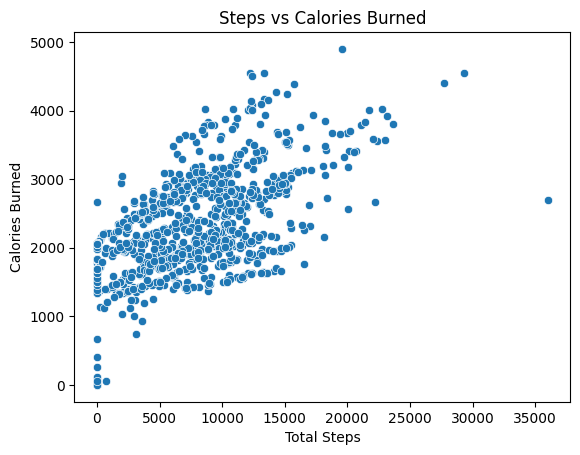

In [18]:
#bar chart- Average activity minutes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.scatterplot(x='TotalSteps', y='Calories', data=activity)

plt.title("Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")

plt.show()

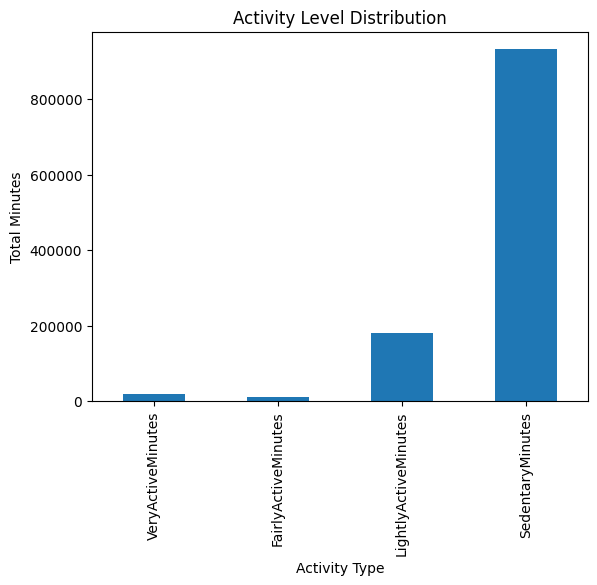

In [19]:
activity_levels = activity[['VeryActiveMinutes',
                            'FairlyActiveMinutes',
                            'LightlyActiveMinutes',
                            'SedentaryMinutes']].sum()

plt.figure()

activity_levels.plot(kind='bar')

plt.title("Activity Level Distribution")
plt.xlabel("Activity Type")
plt.ylabel("Total Minutes")

plt.show()

<Axes: xlabel='ActivityDate'>

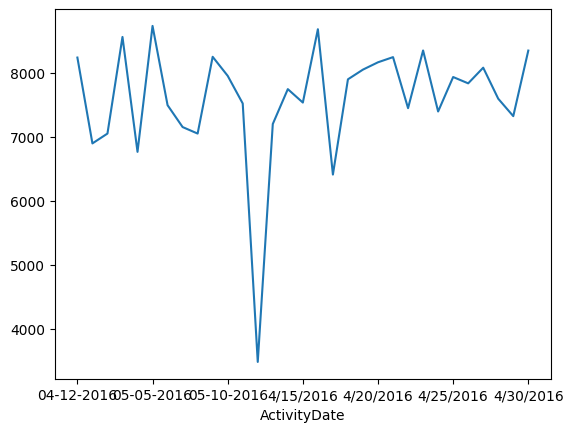

In [ ]:
activity.groupby('ActivityDate')['TotalSteps'].mean().plot()

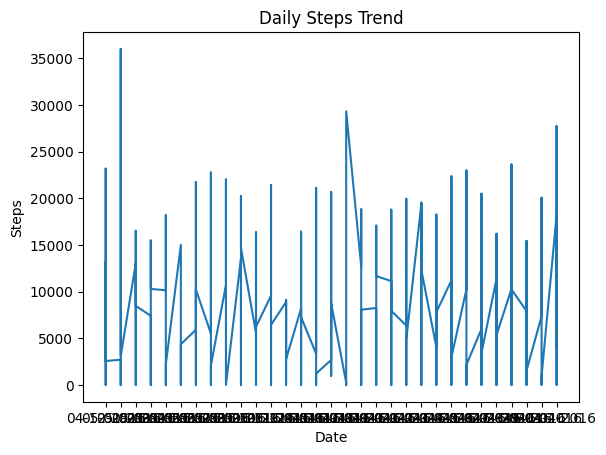

In [ ]:
activity_sorted = activity.sort_values('ActivityDate')

plt.plot(activity_sorted['ActivityDate'], activity_sorted['TotalSteps'])
plt.title("Daily Steps Trend")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dailyCalories_merged.csv to dailyCalories_merged.csv


In [ ]:
Calories= pd.read_csv('dailyCalories_merged.csv')

In [ ]:
Calories['ActivityDay'] = pd.to_datetime(Calories['ActivityDay'], format='mixed', dayfirst=True)

In [ ]:
Calories['ActivityDay'] = Calories['ActivityDay'].dt.strftime('%d-%m-%Y')

In [ ]:
Calories.head(20)

,Id,ActivityDay,Calories
0,1503960366,04-12-2016,1985
1,1503960366,13-04-2016,1797
2,1503960366,14-04-2016,1776
3,1503960366,15-04-2016,1745
4,1503960366,16-04-2016,1863
5,1503960366,17-04-2016,1728
6,1503960366,18-04-2016,1921
7,1503960366,19-04-2016,2035
8,1503960366,20-04-2016,1786
9,1503960366,21-04-2016,1775


In [ ]:
activity.drop_duplicates(inplace=True)

In [ ]:
Calories.describe()

,Id,Calories
count,9.400000e+02,940.000000
mean,4.855407e+09,2303.609574
std,2.424805e+09,718.166862
min,1.503960e+09,0.000000
25%,2.320127e+09,1828.500000
50%,4.445115e+09,2134.000000
75%,6.962181e+09,2793.250000
max,8.877689e+09,4900.000000


In [ ]:
Calories['Calories'].mean()

np.float64(2303.609574468085)

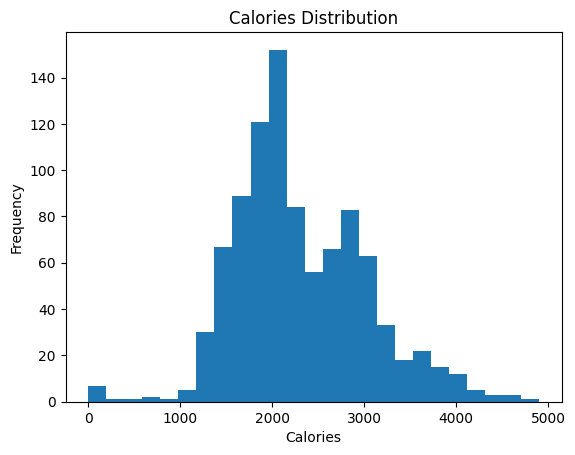

In [ ]:
plt.hist(Calories['Calories'], bins=25)
plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

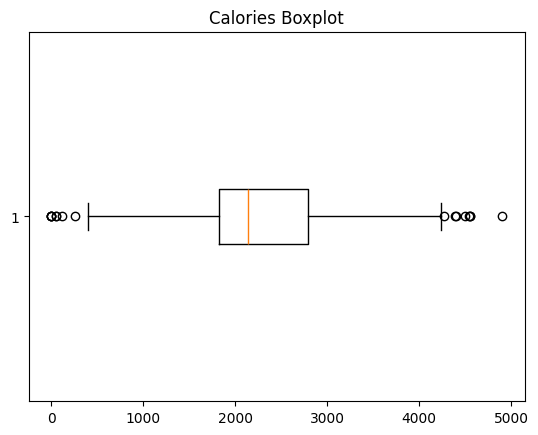

In [ ]:
plt.boxplot(Calories['Calories'], vert=False)
plt.title("Calories Boxplot")
plt.show()

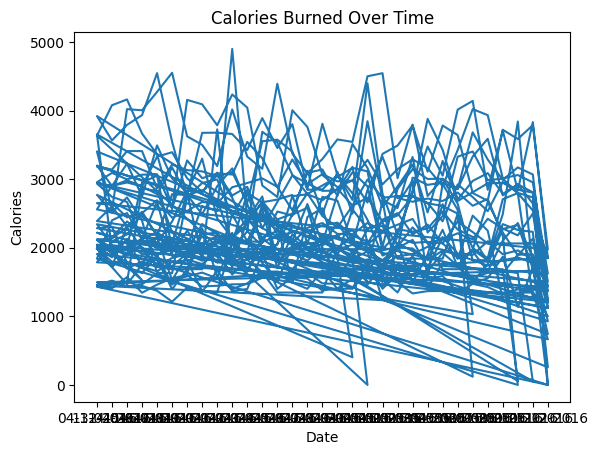

In [ ]:
plt.plot(Calories['ActivityDay'], Calories['Calories'])
plt.title("Calories Burned Over Time")
plt.xlabel("Date")
plt.ylabel("Calories")
plt.show()

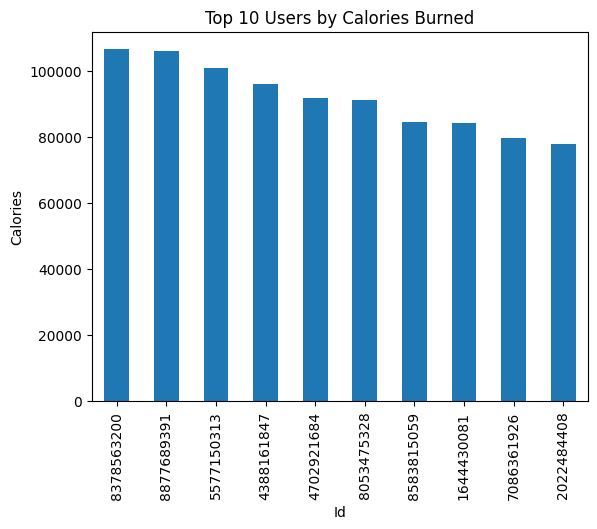

In [ ]:
top_cal = Calories.groupby('Id')['Calories'].sum().sort_values(ascending=False).head(10)

top_cal.plot(kind='bar')
plt.title("Top 10 Users by Calories Burned")
plt.ylabel("Calories")
plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dailySteps_merged.csv to dailySteps_merged.csv


In [ ]:
steps=pd.read_csv('dailySteps_merged.csv')

In [ ]:
steps['ActivityDay'] = pd.to_datetime(steps['ActivityDay'], format='mixed', dayfirst=True)

In [ ]:
steps['ActivityDay'] = steps['ActivityDay'].dt.strftime('%d-%m-%Y')

In [ ]:
steps.head(20)

,Id,ActivityDay,StepTotal
0,1503960366,04-12-2016,13162
1,1503960366,13-04-2016,10735
2,1503960366,14-04-2016,10460
3,1503960366,15-04-2016,9762
4,1503960366,16-04-2016,12669
5,1503960366,17-04-2016,9705
6,1503960366,18-04-2016,13019
7,1503960366,19-04-2016,15506
8,1503960366,20-04-2016,10544
9,1503960366,21-04-2016,9819


In [ ]:
steps.drop_duplicates(inplace=True)

In [ ]:
steps.describe()

,Id,StepTotal
count,9.400000e+02,940.000000
mean,4.855407e+09,7637.910638
std,2.424805e+09,5087.150742
min,1.503960e+09,0.000000
25%,2.320127e+09,3789.750000
50%,4.445115e+09,7405.500000
75%,6.962181e+09,10727.000000
max,8.877689e+09,36019.000000


In [ ]:
steps['StepTotal'].mean()

np.float64(7637.9106382978725)

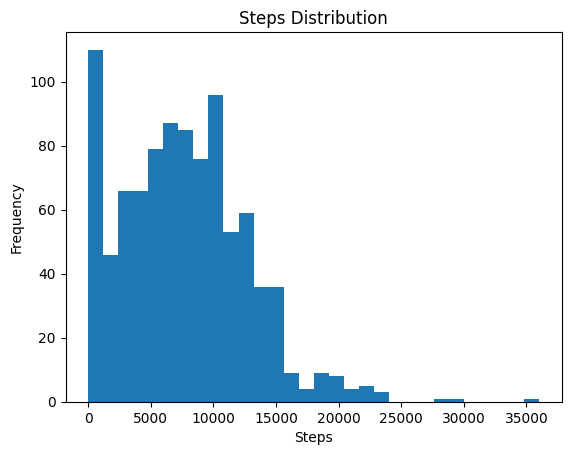

In [ ]:
plt.hist(steps['StepTotal'], bins=30)
plt.title("Steps Distribution")
plt.xlabel("Steps")
plt.ylabel("Frequency")
plt.show()

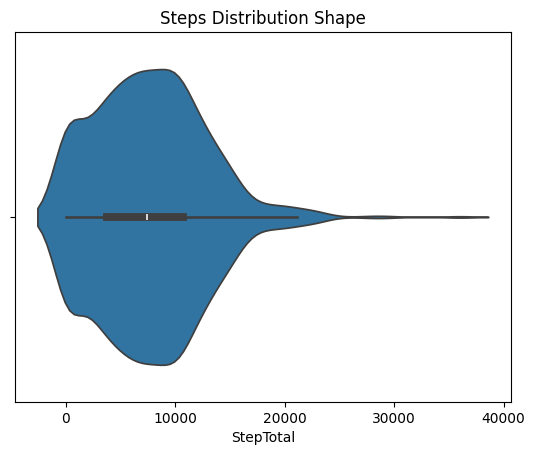

In [ ]:
import seaborn as sns

sns.violinplot(x=steps['StepTotal'])
plt.title("Steps Distribution Shape")
plt.show()

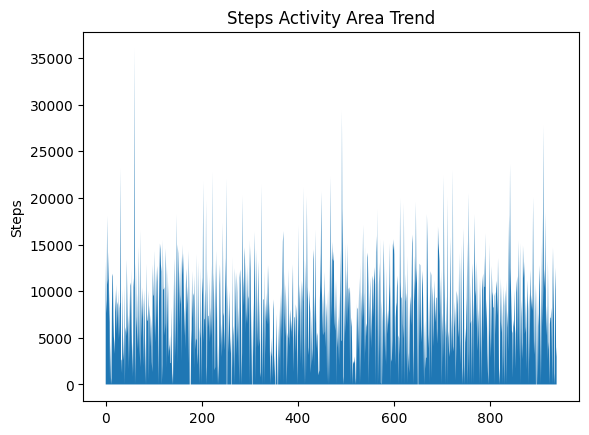

In [ ]:
steps_sorted = steps.sort_values('ActivityDay')

plt.fill_between(range(len(steps_sorted)), steps_sorted['StepTotal'])
plt.title("Steps Activity Area Trend")
plt.ylabel("Steps")
plt.show()

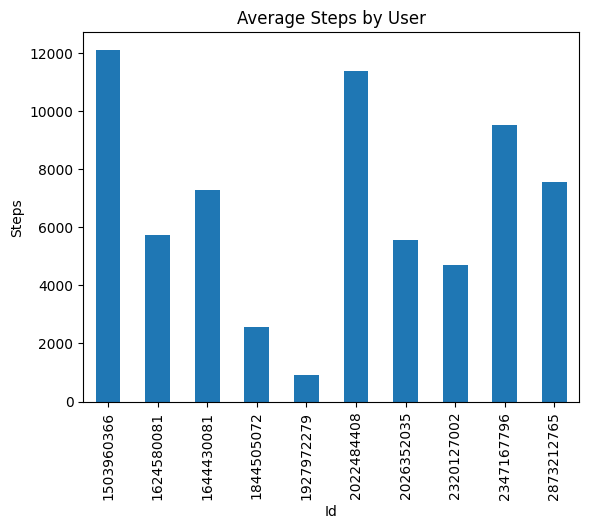

In [ ]:
avg_steps = steps.groupby('Id')['StepTotal'].mean().head(10)

avg_steps.plot(kind='bar')
plt.title("Average Steps by User")
plt.ylabel("Steps")
plt.show()

In [20]:
from google.colab import files
uploaded = files.upload()


Saving sleepDay_merged.csv to sleepDay_merged.csv


In [21]:
sleep = pd.read_csv('sleepDay_merged.csv')

In [24]:
sleep.head(20)

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,04-12-2016 00:00,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712
5,1503960366,4/19/2016 12:00:00 AM,1,304,320
6,1503960366,4/20/2016 12:00:00 AM,1,360,377
7,1503960366,4/21/2016 12:00:00 AM,1,325,364
8,1503960366,4/23/2016 12:00:00 AM,1,361,384
9,1503960366,4/24/2016 12:00:00 AM,1,430,449


In [ ]:
sleep.head(20)

,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed,Time
0,1503960366,2016-12-04,1,327,346,00:00:00
1,1503960366,2016-04-13,2,384,407,00:00:00
2,1503960366,2016-04-15,1,412,442,00:00:00
3,1503960366,2016-04-16,2,340,367,00:00:00
4,1503960366,2016-04-17,1,700,712,00:00:00
5,1503960366,2016-04-19,1,304,320,00:00:00
6,1503960366,2016-04-20,1,360,377,00:00:00
7,1503960366,2016-04-21,1,325,364,00:00:00
8,1503960366,2016-04-23,1,361,384,00:00:00
9,1503960366,2016-04-24,1,430,449,00:00:00


In [ ]:
sleep.describe()


,Id,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
count,4.130000e+02,413.000000,413.000000,413.000000
mean,5.000979e+09,1.118644,419.467312,458.639225
std,2.060360e+09,0.345521,118.344679,127.101607
min,1.503960e+09,1.000000,58.000000,61.000000
25%,3.977334e+09,1.000000,361.000000,403.000000
50%,4.702922e+09,1.000000,433.000000,463.000000
75%,6.962181e+09,1.000000,490.000000,526.000000
max,8.792010e+09,3.000000,796.000000,961.000000


In [ ]:
sleep[['TotalMinutesAsleep','TotalTimeInBed']].corr()

,TotalMinutesAsleep,TotalTimeInBed
TotalMinutesAsleep,1.000000,0.930457
TotalTimeInBed,0.930457,1.000000


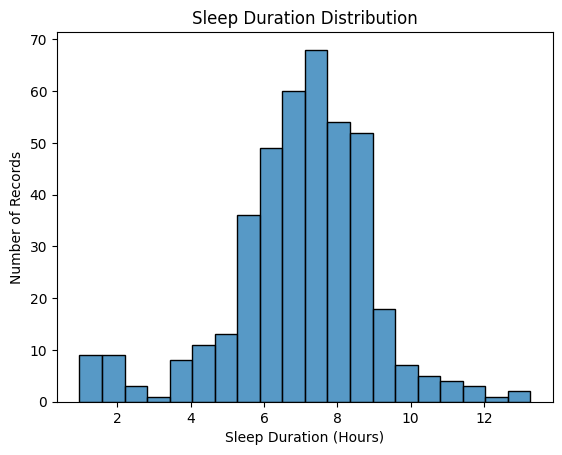

In [29]:
sleep['SleepHours'] = sleep['TotalMinutesAsleep'] / 60

plt.figure()

sns.histplot(sleep['SleepHours'], bins=20)

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Number of Records")

plt.show()

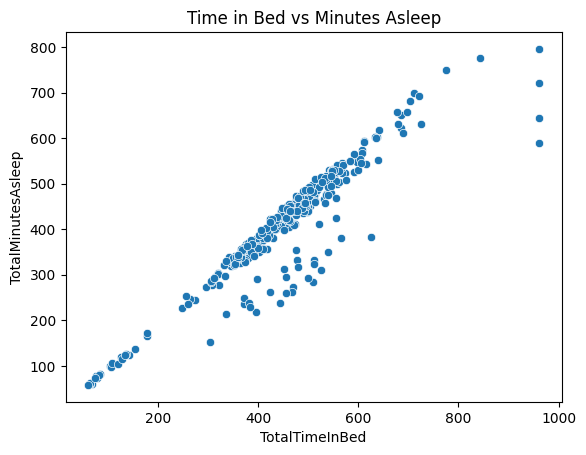

In [ ]:
sns.scatterplot(x='TotalTimeInBed', y='TotalMinutesAsleep', data=sleep)
plt.title("Time in Bed vs Minutes Asleep")
plt.show()

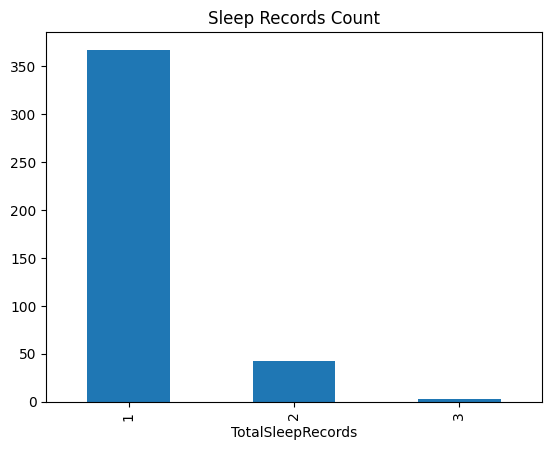

In [ ]:
sleep['TotalSleepRecords'].value_counts().plot(kind='bar')
plt.title("Sleep Records Count")
plt.show()

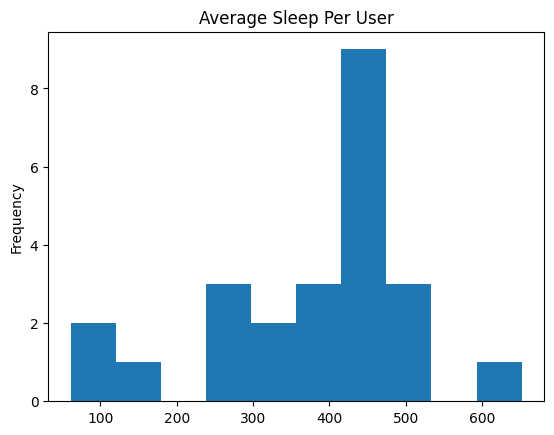

In [28]:
sleep.groupby('Id')['TotalMinutesAsleep'].mean().plot(kind='hist')
plt.title("Average Sleep Per User")
plt.show()

In [31]:
from google.colab import files
uploaded = files.upload()


Saving weightLogInfo_merged.csv to weightLogInfo_merged.csv


In [32]:
weight=pd.read_csv('weightLogInfo_merged.csv')

In [33]:
weight['Date'] = pd.to_datetime(weight['Date'], format='mixed', dayfirst=True)

In [34]:
weight['Date'] = weight['Date'].dt.date

In [35]:
weight.drop(columns=['Fat'], inplace=True)

In [36]:
weight.head()

,Id,Date,WeightKg,WeightPounds,BMI,IsManualReport,LogId
0,1503960366,2016-02-05,52.599998,115.963146,22.650000,True,1.460000e+12
1,1503960366,2016-03-05,52.599998,115.963146,22.650000,True,1.460000e+12
2,1927972279,2016-04-13,133.500000,294.317120,47.540001,False,1.460000e+12
3,2873212765,2016-04-21,56.700001,125.002104,21.450001,True,1.460000e+12
4,2873212765,2016-12-05,57.299999,126.324875,21.690001,True,1.460000e+12


In [37]:
weight.describe()

,Id,WeightKg,WeightPounds,BMI,LogId
count,6.700000e+01,67.000000,67.000000,67.000000,6.700000e+01
mean,7.009282e+09,72.035821,158.811801,25.185224,1.460000e+12
std,1.950322e+09,13.923206,30.695415,3.066963,0.000000e+00
min,1.503960e+09,52.599998,115.963146,21.450001,1.460000e+12
25%,6.962181e+09,61.400002,135.363832,23.959999,1.460000e+12
50%,6.962181e+09,62.500000,137.788914,24.389999,1.460000e+12
75%,8.877689e+09,85.049999,187.503152,25.559999,1.460000e+12
max,8.877689e+09,133.500000,294.317120,47.540001,1.460000e+12


In [38]:
weight[['WeightKg','BMI']].corr()

,WeightKg,BMI
WeightKg,1.000000,0.735684
BMI,0.735684,1.000000


In [39]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

weight["BMI_Category"] = weight["BMI"].apply(bmi_category)

In [40]:
weight.head()

,Id,Date,WeightKg,WeightPounds,BMI,IsManualReport,LogId,BMI_Category
0,1503960366,2016-02-05,52.599998,115.963146,22.650000,True,1.460000e+12,Normal
1,1503960366,2016-03-05,52.599998,115.963146,22.650000,True,1.460000e+12,Normal
2,1927972279,2016-04-13,133.500000,294.317120,47.540001,False,1.460000e+12,Obese
3,2873212765,2016-04-21,56.700001,125.002104,21.450001,True,1.460000e+12,Normal
4,2873212765,2016-12-05,57.299999,126.324875,21.690001,True,1.460000e+12,Normal


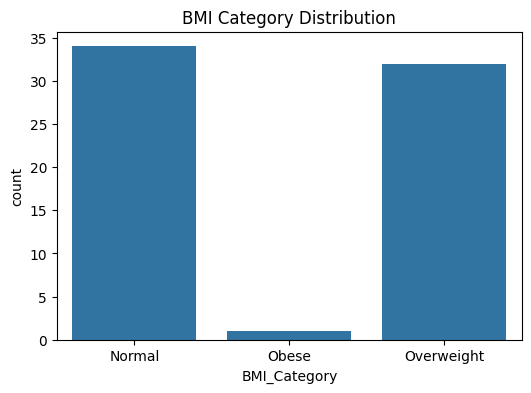

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="BMI_Category", data=weight)

plt.title("BMI Category Distribution")
plt.show()

In [ ]:
weight["BMI_Category"].value_counts(normalize=True)*100

,proportion
BMI_Category,
Normal,50.746269
Overweight,47.761194
Obese,1.492537


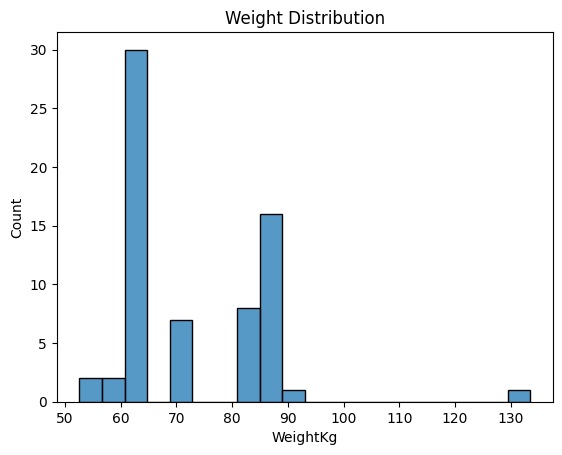

In [ ]:
sns.histplot(weight['WeightKg'], bins=20)
plt.title("Weight Distribution")
plt.show()

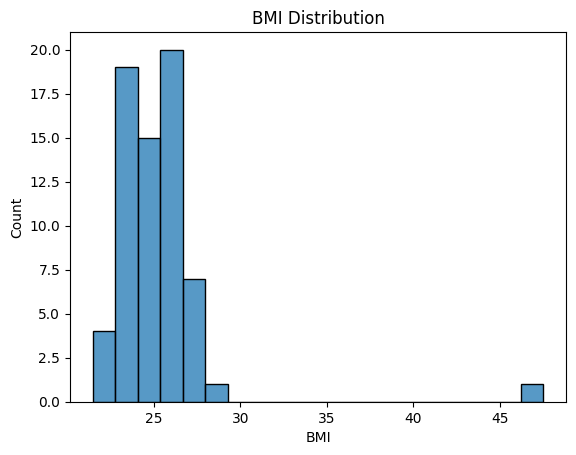

In [ ]:
sns.histplot(weight['BMI'], bins=20)
plt.title("BMI Distribution")
plt.show()

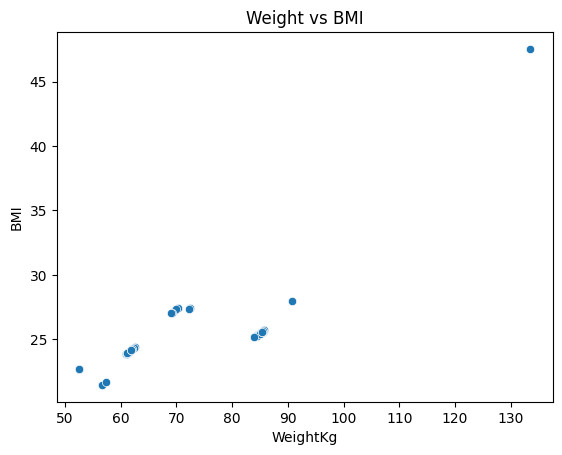

In [ ]:
sns.scatterplot(x='WeightKg', y='BMI', data=weight)
plt.title("Weight vs BMI")
plt.show()

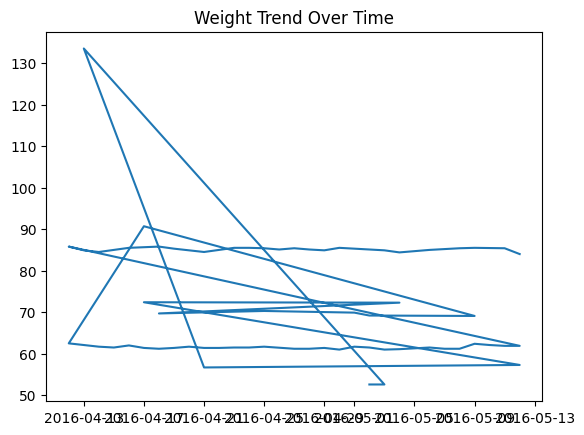

In [ ]:
plt.plot(weight['Date'], weight['WeightKg'])
plt.title("Weight Trend Over Time")
plt.show()

In [30]:
plt.figure()

sns.histplot(weight['BMI'], bins=20, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.show()

NameError: name 'weight' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
print(weight)

            Id        Date    WeightKg  WeightPounds        BMI  \
0   1503960366  2016-02-05   52.599998    115.963146  22.650000   
1   1503960366  2016-03-05   52.599998    115.963146  22.650000   
2   1927972279  2016-04-13  133.500000    294.317120  47.540001   
3   2873212765  2016-04-21   56.700001    125.002104  21.450001   
4   2873212765  2016-12-05   57.299999    126.324875  21.690001   
..         ...         ...         ...           ...        ...   
62  8877689391  2016-06-05   85.000000    187.392923  25.440001   
63  8877689391  2016-08-05   85.400002    188.274775  25.559999   
64  8877689391  2016-09-05   85.500000    188.495234  25.610001   
65  8877689391  2016-11-05   85.400002    188.274775  25.559999   
66  8877689391  2016-12-05   84.000000    185.188300  25.139999   

    IsManualReport         LogId BMI_Category  
0             True  1.460000e+12       Normal  
1             True  1.460000e+12       Normal  
2            False  1.460000e+12        Obese  
3  

In [ ]:
weight.to_csv("fitness_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("fitness_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 40.7 MB/s eta 0:00:00
